# Magneto-Stokes Flow in a Shallow Free-Surface Annulus

Cy S. David, Eric W. Hester, Yufan Xu, and Jonathan M. Aurnou

In [1]:
from magnetoStokes.magnetoStokes import magStokes
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format='retina'
import pandas as pd

This notebook demonstrates how to use the `magStokes` package to quickly compute theoretical predictions for magnetohydrodynamically-pumped flow in a shallow free-surface annulus.

## Theory

Consider a layer of conducting fluid of depth $h$ in the annular gap between two cylindrical electrodes of radius $r_i$ and $r_o$ ($r_i<r_o$). A current $I$ runs through the fluid from inner to outer electrode, and the entire annulus is immersed in a vertical, imposed magnetic field $\boldsymbol{B_0} =  -B_0 \boldsymbol{e_z}$. Figure 1(a) shows a schematic of the annular channel with imposed magnetic field and current. Figure 1(b) shows the actual laboratory device with a spiral of blue dye that reveals the swirling flow.

![Diagram.jpg](images/Diagram.jpg)

When the power supply is turned on, the fluid experiences an azimuthal electromagnetic force that drives circulatory flow against viscous drag.

The dimensionless axisymmetric solution for spin-up from rest may be approximated as

$${u}^*_\theta(\tilde{r},\tilde{z},\tilde{t}) =  \left\{\sum_{n=1}^{\infty} \frac{2(\chi+1)}{k_n^2 \gamma} \left[ \frac{\gamma}{k_n \tilde{r}}-A_n I_1\left( \frac{k_n}{ \gamma}\tilde{r}\right) - B_n K_1\left( \frac{k_n}{ \gamma}\tilde{r}\right) \right]\sin (k_n  \tilde{z}) \right\}\times \left[1- \exp\left(-\frac{\pi ^2}{4 \textit{Re}_C}\tilde{t}\right)\right]$$

where  

$ A_n=\frac{\gamma}{k_n \chi}\left[\frac{\chi  K_ 1\left({k_n \chi}/{\gamma }\right)-K_ 1\left({k_n }/{\gamma}\right)}{I_1\left({k_n}/{\gamma }\right) K_1\left({k_n\chi }/{\gamma}\right)-K_1\left({k_n}/{\gamma\\}\right) I_1\left({k_n \chi }/{\gamma}\right)}\right]$,  $B_n=\frac{I_ 1\left({k_n}/{\gamma}\right)-\chi  I_1\left({k_n\chi }/{\gamma}\right)}{\chi  K_1\left({k_n \chi}/{\gamma }\right)-K_1\left({k_n }/{\gamma}\right)} A_n$,  

$k_n=\pi (n-1/2)$,  $\textit{Re}_C = ({h^2/\nu})/({(r_i+r_o)/\mathcal{U}_\text{MS}})$, $\chi = r_i/r_o$, and $\gamma = h/r_o$,

with dimensionless coordinates

$\tilde{r} = r/r_o$,    $\tilde{z}=z/h$,   $t=\tilde{t}(r_i+r_o)/\mathcal{U}_\text{MS}$,  

and velocity scale

$\mathcal{U}_\text{MS} =B_0 h I/(2 \pi  \nu  \rho (r_i+r_o))$.

## Example 1: Plot analytical solution

Create an instance of the `magStokes` class for a flow with 0.4 cm fluid layer depth, 4 cm inner cylinder radius, 18 cm outer cylinder radius, 0.03 Tesla (300 Gauss) magnetic field strength, and 0.08 A applied current:

In [2]:
flow = magStokes(h=0.004,r_i=0.04,r_o=0.18,B=0.03,Imax=0.08)

Compute the density and viscosity for a saltwater solution with 80 ppt NaCl:H2O. Note that the `.customFluidProps()` method may be used to manually enter viscosity and density for an arbitrary fluid.

In [3]:
flow.saltwaterProps(S=80)

Print the computed aspect ratios, control Reynolds number, and velocity scale:

In [4]:
print(flow) 

χ = 0.22, γ = 0.02, ReC = 0.38, U = 5.86e-03 m/s


Use the `.u()` method to compute the solution for an initially-quiescent flow 20 seconds after the power supply (I = 0.08 A) is turned on.

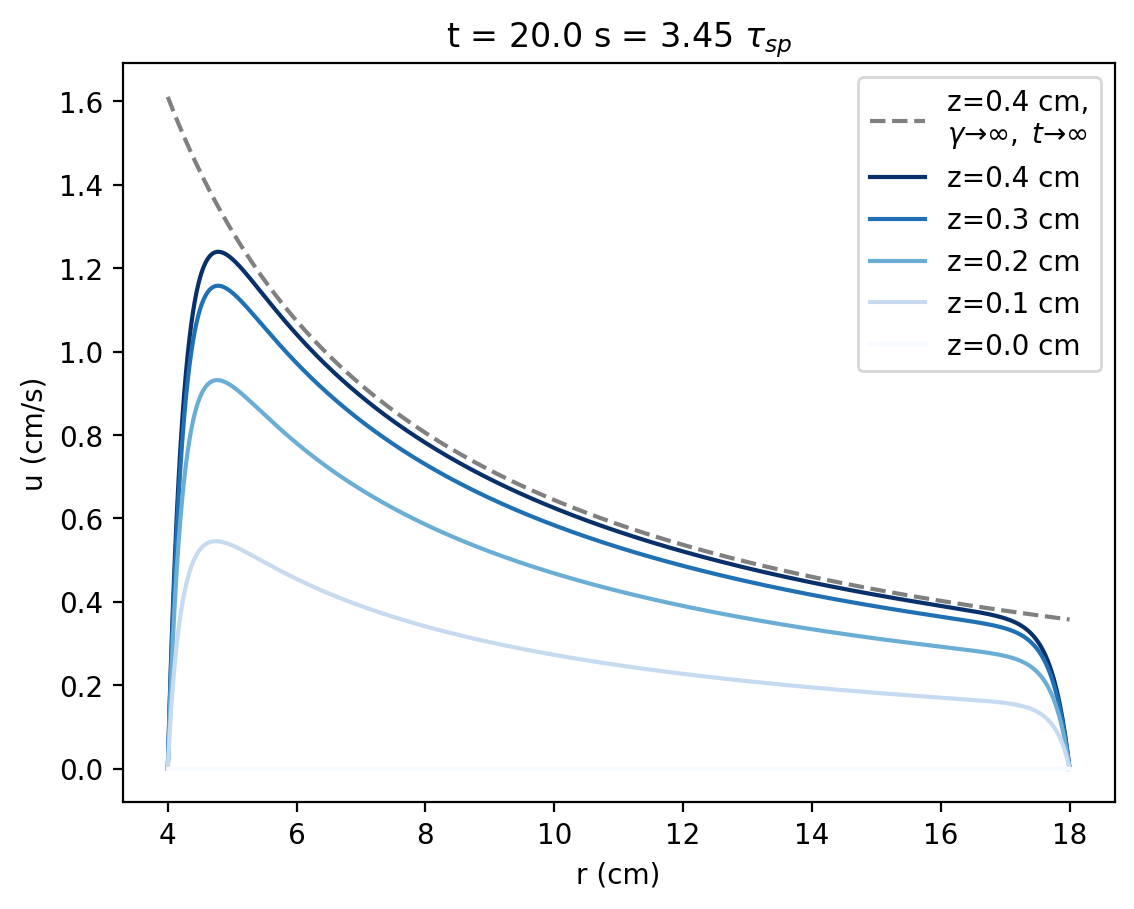

In [10]:
# Independent variables
t = 20 # seconds
rArr = np.linspace(flow.r_i,flow.r_o,1001)
zArr = np.linspace(flow.h,0,5)

# Compute the steady solution in the shallow limit
# (dashed gray line)
u1DArr = flow.uShallow(r=rArr,z=flow.h)

# Compute and plot 2D solution at each depth in `zArr`
# using the `.u()` method
cmap = matplotlib.cm.get_cmap('Blues')
plt.plot(1e2*rArr,1e2*u1DArr,color='gray',linestyle='--',
         label=f'z={1e2*flow.h:.1f} cm,\n$\\gamma\\to\\infty,\\; t\\to\\infty$')
for z in zArr:
    uArr = flow.u(r=rArr,z=z,t=t)
    plt.plot(1e2*rArr,1e2*uArr,color=cmap(z/flow.h),label=f'z={1e2*z:.1f} cm')
plt.xlabel('r (cm)')
plt.ylabel('u (cm/s)')
plt.legend()
plt.title(f't = {t:.1f} s = {t/flow.Tsp:.2f} $\\tau_{{sp}}$')
#plt.savefig('images/Soln.jpg',dpi=300)
plt.show()

## Example 2: Compute scales and dimensionless parameters

Read in (dimensional) experimental parameters:

In [6]:
DimExpParam = pd.read_csv('example_data.csv')

Compute aspect ratios, control Reyolds number, velocity scale, and time scales from dimensional experimental parameters:

In [7]:
compData = []

for i in range(DimExpParam.shape[0]):
    run = DimExpParam['RUN'][i]
    h = 1e-2*DimExpParam['Height fluid (cm)'][i]
    r_i = 1e-2*DimExpParam['Inner radius (cm)'][i]
    r_o = 1e-2*DimExpParam['Outer radius (cm)'][i]
    Imax = DimExpParam['Current (A)'][i]
    B = 1e-4*DimExpParam['Magnetic field (Gauss)'][i]
    S = DimExpParam['Salinity (ppt)'][i]

    # Create magStokes instance with specified parameters
    labFlow = magStokes(h=h,r_i=r_i,r_o=r_o,B=B,Imax=Imax)
    # Input salinity. Compute dimensionless numbers and scales
    labFlow.saltwaterProps(S=S)

    # Store dimensionless numbers and scales
    computedParams = [run, labFlow.γ, labFlow.χ, labFlow.ReC, labFlow.U, labFlow.T, labFlow.Tcirc, labFlow.Tsp]
    compData.append(computedParams)

compDataDf = pd.DataFrame(compData,columns=['Case','gamma','chi','ReC','U (m/s)','T (s)','Tcirc (s)','Tsp (s)'])

pd.set_option('display.float_format',  '{:.1e}'.format)
compDataDf

,Case,gamma,chi,ReC,U (m/s),T (s),Tcirc (s),Tsp (s)
0,RUN A3,2.3e-02,2.5e-01,3.8e-01,5.9e-03,3.7e+01,1.2e+02,5.8e+00
1,RUN C2,2.3e-02,4.4e-01,3.6e-01,6.4e-03,3.9e+01,1.2e+02,5.8e+00
2,RUN D1,4.6e-02,4.4e-01,7.8e-01,3.4e-03,7.4e+01,2.3e+02,2.3e+01
3,RUN E1,2.3e-02,5.8e-01,3.5e-01,6.8e-03,4.1e+01,1.3e+02,5.8e+00


Export computed values:

In [8]:
compDataDf.to_csv('example_compData.csv')